# 🏦 FinGuard AI — Model Training

### AI-Powered Financial Fraud Detection & Risk Intelligence Platform

**Notebook:** 05 — Model Training  
**Project:** FinGuard AI  
**Objective:** Train and compare supervised fraud-detection models using the feature-engineered datasets.

---

#### 1. Objective

This notebook trains multiple classification models for financial fraud detection.

The training workflow includes:

- Loading feature-engineered training and testing data
- Validating feature consistency
- Training multiple supervised models
- Evaluating fraud-focused metrics
- Comparing model performance
- Saving trained models and evaluation results
- Selecting the best model for downstream prediction

**Important:** The test set is never SMOTE-balanced and is used only for final evaluation.

#### 2. Model Training Strategy

Models included in this stage:

1. Logistic Regression — baseline
2. Random Forest — robust tree ensemble
3. XGBoost — gradient-boosted fraud classifier
4. HistGradientBoosting — efficient gradient-boosting classifier

The primary selection criteria are **F1-score, Recall, Precision, PR-AUC and ROC-AUC**, not accuracy alone.

In [1]:
# ============================================================
# FinGuard AI — Model Training Environment Setup
# ============================================================

import sys
import warnings
from pathlib import Path
import json
import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("FinGuard AI — Model Training")
print("=" * 70)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

FinGuard AI — Model Training
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5


#### 3. Project Paths

In [2]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "Dataset"
PROCESSED_DIR = DATASET_DIR / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
REPORT_DIR = PROJECT_ROOT / "Reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "feature_engineered_train.csv"
BALANCED_TRAIN_PATH = PROCESSED_DIR / "feature_engineered_train_balanced.csv"
TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"

FEATURE_METADATA_PATH = MODEL_DIR / "feature_engineering_metadata.joblib"

print("Project Root :", PROJECT_ROOT)
print("Training     :", TRAIN_PATH)
print("Balanced     :", BALANCED_TRAIN_PATH)
print("Testing      :", TEST_PATH)
print("Models       :", MODEL_DIR)

Project Root : C:\Users\viqua\Desktop\FinGuard AI
Training     : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train.csv
Balanced     : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train_balanced.csv
Testing      : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
Models       : C:\Users\viqua\Desktop\FinGuard AI\Models


#### 4. Input Validation

In [3]:
# ============================================================
# Validate Required Artifacts
# ============================================================

required_files = [
    TRAIN_PATH,
    BALANCED_TRAIN_PATH,
    TEST_PATH,
    FEATURE_METADATA_PATH
]

for path in required_files:
    status = "✓ EXISTS" if path.exists() else "✗ MISSING"
    print(f"{status:12} {path}")

missing = [p for p in required_files if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Required feature-engineering artifacts are missing."
    )

print("\n✓ Input artifact validation passed")

✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train_balanced.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\feature_engineering_metadata.joblib

✓ Input artifact validation passed


#### 5. Load Feature-Engineered Data

In [4]:
# ============================================================
# Load Data
# ============================================================

print("Loading feature-engineered datasets...")

train_df = pd.read_csv(TRAIN_PATH)
balanced_train_df = pd.read_csv(BALANCED_TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("✓ Datasets loaded successfully")
print("-" * 70)
print(f"Training samples         : {len(train_df):,}")
print(f"Balanced training samples: {len(balanced_train_df):,}")
print(f"Testing samples          : {len(test_df):,}")
print(f"Training columns         : {train_df.shape[1]}")
print(f"Testing columns          : {test_df.shape[1]}")

Loading feature-engineered datasets...
✓ Datasets loaded successfully
----------------------------------------------------------------------
Training samples         : 226,980
Balanced training samples: 453,204
Testing samples          : 56,746
Training columns         : 54
Testing columns          : 54


#### 6. Target and Feature Validation

In [5]:
# ============================================================
# Target / Feature Validation
# ============================================================

TARGET = "Class"

if (
    TARGET not in train_df.columns
    or TARGET not in balanced_train_df.columns
    or TARGET not in test_df.columns
):
    raise KeyError(
        f"Target column '{TARGET}' must exist in all datasets."
    )

feature_columns = [
    c for c in train_df.columns
    if c != TARGET
]

if feature_columns != [
    c for c in test_df.columns
    if c != TARGET
]:
    raise ValueError(
        "Training and testing feature order does not match."
    )

if feature_columns != [
    c for c in balanced_train_df.columns
    if c != TARGET
]:
    raise ValueError(
        "Balanced training and normal training feature order does not match."
    )

print("Target column :", TARGET)
print("Feature count :", len(feature_columns))
print("✓ Feature order validation passed")

print("\nTarget distribution — original training:")
display(
    train_df[TARGET]
    .value_counts()
    .rename_axis(TARGET)
    .to_frame("Count")
)

print("\nTarget distribution — balanced training:")
display(
    balanced_train_df[TARGET]
    .value_counts()
    .rename_axis(TARGET)
    .to_frame("Count")
)

Target column : Class
Feature count : 53
✓ Feature order validation passed

Target distribution — original training:


,Count
Class,
0,226602
1,378



Target distribution — balanced training:


,Count
Class,
0,226602
1,226602


#### 7. Prepare Training and Testing Matrices

For model development, the balanced training set is used to reduce the extreme fraud-class imbalance. The untouched test set remains representative of real-world class prevalence.

In [6]:
# ============================================================
# Prepare Training and Testing Matrices
# ============================================================

X_train = balanced_train_df[feature_columns].copy()
y_train = balanced_train_df[TARGET].astype(int).copy()

X_train_original = train_df[feature_columns].copy()
y_train_original = train_df[TARGET].astype(int).copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

# Safety checks
if X_train.isnull().any().any() or X_test.isnull().any().any():
    raise ValueError("Missing values detected in model features.")

if np.isinf(X_train.to_numpy()).any() or np.isinf(X_test.to_numpy()).any():
    raise ValueError("Infinite values detected in model features.")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)
print("✓ Model matrices prepared")

X_train : (453204, 53)
y_train : (453204,)
X_test  : (56746, 53)
y_test  : (56746,)
✓ Model matrices prepared


#### 8. Model Configuration

In [7]:
# ============================================================
# Model Configuration
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=None,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        n_jobs=-1,
        random_state=42,
        class_weight=None
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=150,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=15,
        random_state=42
    )
}

print("Configured models:")
for name in models:
    print("✓", name)

Configured models:
✓ Logistic Regression
✓ Random Forest
✓ XGBoost
✓ HistGradientBoosting


#### 9. Training and Evaluation Function

In [8]:
# ============================================================
# Training / Evaluation Function
# ============================================================

def evaluate_model(name, model, X_fit, y_fit, X_eval, y_eval):

    start = time.time()

    model.fit(X_fit, y_fit)

    train_time = time.time() - start

    predictions = model.predict(X_eval)

    if not hasattr(model, "predict_proba"):
        raise AttributeError(
            f"{name} does not provide probability estimates."
        )

    probabilities = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(
            y_eval, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_eval, predictions, zero_division=0
        ),
        "F1_Score": f1_score(
            y_eval, predictions, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_eval, probabilities
        ),
        "PR_AUC": average_precision_score(
            y_eval, probabilities
        ),
        "Training_Time_Seconds": train_time
    }

    return model, predictions, probabilities, metrics

#### 10. Train Models

In [9]:
# ============================================================
# Train Models
# ============================================================

trained_models = {}
predictions = {}
probabilities = []
results = []

for name, model in models.items():

    print(f"\nTraining: {name}")

    trained_model, pred, prob, metrics = evaluate_model(
        name,
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    trained_models[name] = trained_model
    predictions[name] = pred
    probabilities.append(prob)
    results.append(metrics)

    print(f"✓ Completed in {metrics['Training_Time_Seconds']:.2f} seconds")
    print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    print(f"  F1-score  : {metrics['F1_Score']:.4f}")
    print(f"  PR-AUC    : {metrics['PR_AUC']:.4f}")
    print(f"  ROC-AUC   : {metrics['ROC_AUC']:.4f}")


Training: Logistic Regression
✓ Completed in 146.84 seconds
  Accuracy  : 0.9700
  Precision : 0.0468
  Recall    : 0.8737
  F1-score  : 0.0889
  PR-AUC    : 0.6574
  ROC-AUC   : 0.9608

Training: Random Forest
✓ Completed in 1486.81 seconds
  Accuracy  : 0.9995
  Precision : 0.9324
  Recall    : 0.7263
  F1-score  : 0.8166
  PR-AUC    : 0.8004
  ROC-AUC   : 0.9703

Training: XGBoost
✓ Completed in 51.58 seconds
  Accuracy  : 0.9991
  Precision : 0.7212
  Recall    : 0.7895
  F1-score  : 0.7538
  PR-AUC    : 0.8141
  ROC-AUC   : 0.9703

Training: HistGradientBoosting
✓ Completed in 55.16 seconds
  Accuracy  : 0.9987
  Precision : 0.5865
  Recall    : 0.8211
  F1-score  : 0.6842
  PR-AUC    : 0.8138
  ROC-AUC   : 0.9680


#### 11. Model Comparison

In [10]:
# ============================================================
# Model Comparison
# ============================================================

results_df = pd.DataFrame(results).sort_values(
    by=["F1_Score", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Training_Time_Seconds": "{:.2f}"
    })
)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_row = results_df.iloc[0]

print(
    f"\n🏆 Best model by fraud-focused ranking: {best_model_name}"
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Training_Time_Seconds
0,Random Forest,0.9995,0.9324,0.7263,0.8166,0.9703,0.8004,1486.81
1,XGBoost,0.9991,0.7212,0.7895,0.7538,0.9703,0.8141,51.58
2,HistGradientBoosting,0.9987,0.5865,0.8211,0.6842,0.9680,0.8138,55.16
3,Logistic Regression,0.9700,0.0468,0.8737,0.0889,0.9608,0.6574,146.84



🏆 Best model by fraud-focused ranking: Random Forest


#### 12. Confusion Matrices

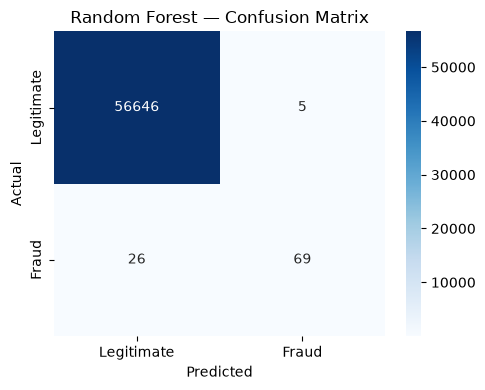

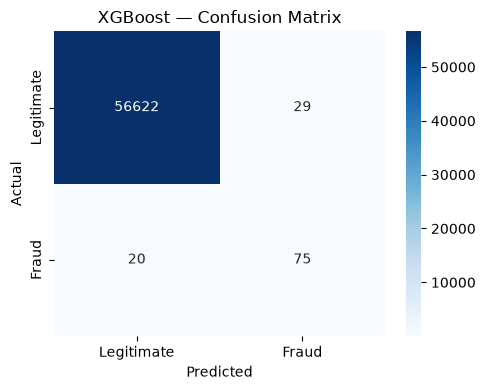

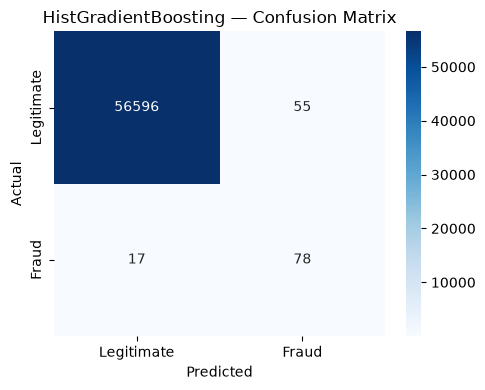

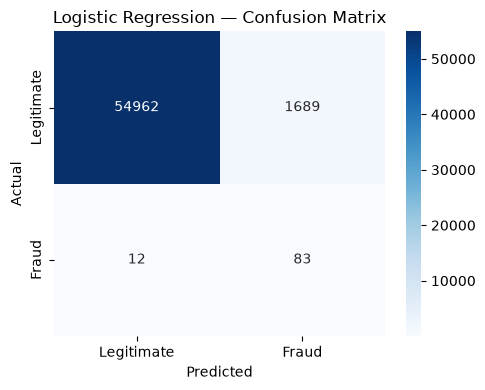

In [11]:
# ============================================================
# Confusion Matrices
# ============================================================

for name in results_df["Model"]:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"]
    )

    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#### 13. Best Model Classification Report

In [12]:
# ============================================================
# Best Model Classification Report
# ============================================================

print(f"Classification Report — {best_model_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        predictions[best_model_name],
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

Classification Report — Random Forest
              precision    recall  f1-score   support

  Legitimate     0.9995    0.9999    0.9997     56651
       Fraud     0.9324    0.7263    0.8166        95

    accuracy                         0.9995     56746
   macro avg     0.9660    0.8631    0.9081     56746
weighted avg     0.9994    0.9995    0.9994     56746



#### 14. Feature Importance — Tree Models

,Feature,Importance
14,V14,0.121295
44,V_Abs_Std,0.095183
10,V10,0.094014
45,V_L2_Norm,0.066009
50,Risk_Max_Deviation,0.062030
4,V4,0.054702
43,V_Abs_Max,0.054600
42,V_Abs_Mean,0.041044
12,V12,0.039102
49,Risk_Deviation_Score,0.037965


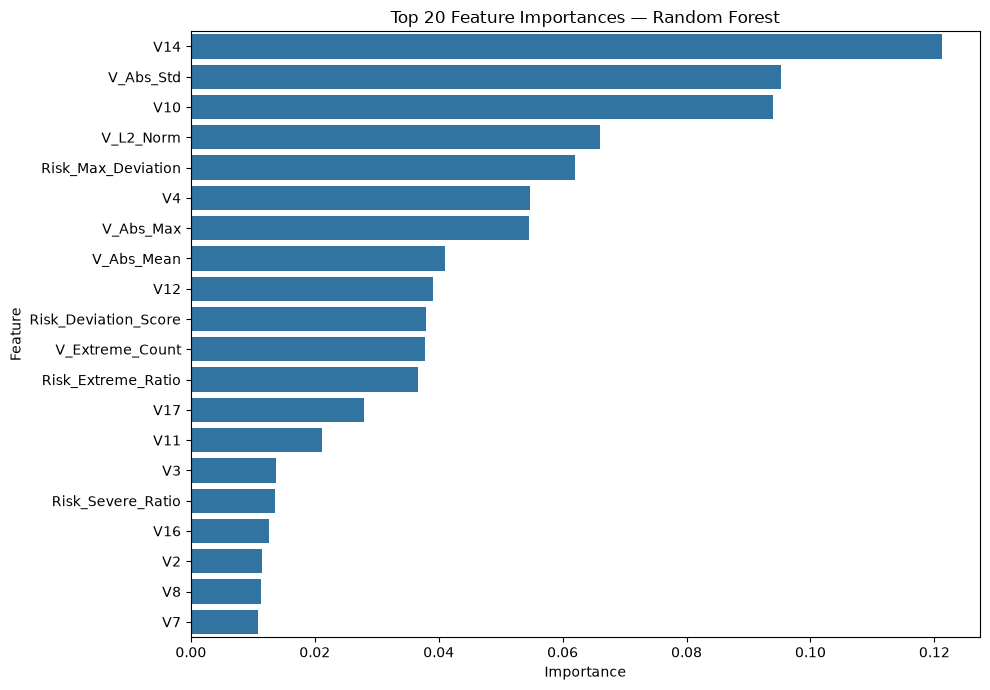

In [13]:
# ============================================================
# Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    ).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 20 Feature Importances — {best_model_name}"
    )
    plt.tight_layout()
    plt.show()

else:
    print(
        f"{best_model_name} does not expose tree-based "
        "feature_importances_."
    )

#### 15. Save Trained Models

In [14]:
# ============================================================
# Save Models
# ============================================================

model_filenames = {
    "Logistic Regression": "logistic_regression_model.joblib",
    "Random Forest": "random_forest_model.joblib",
    "XGBoost": "xgboost_model.joblib",
    "HistGradientBoosting": "hist_gradient_boosting_model.joblib"
}

for name, model in trained_models.items():

    model_path = MODEL_DIR / model_filenames[name]

    joblib.dump(
        model,
        model_path
    )

    print(f"✓ Saved: {model_path}")

best_model_path = MODEL_DIR / "best_fraud_model.joblib"

joblib.dump(
    best_model,
    best_model_path
)

print(f"\n✓ Best model saved: {best_model_path}")

✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Models\logistic_regression_model.joblib
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Models\random_forest_model.joblib
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Models\xgboost_model.joblib
✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Models\hist_gradient_boosting_model.joblib

✓ Best model saved: C:\Users\viqua\Desktop\FinGuard AI\Models\best_fraud_model.joblib


#### 16. Save Evaluation Results and Metadata

In [15]:
# ============================================================
# Save Evaluation Results / Metadata
# ============================================================

results_path = REPORT_DIR / "model_comparison.csv"

results_df.to_csv(
    results_path,
    index=False
)

training_metadata = {
    "project": "FinGuard AI",
    "target": TARGET,
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "training_samples_balanced": int(len(X_train)),
    "training_samples_original": int(len(X_train_original)),
    "testing_samples": int(len(X_test)),
    "models_trained": list(trained_models.keys()),
    "best_model": best_model_name,
    "selection_priority": [
        "F1_Score",
        "PR_AUC",
        "Recall"
    ],
    "test_set_smote": False
}

metadata_path = MODEL_DIR / "model_training_metadata.joblib"

joblib.dump(
    training_metadata,
    metadata_path
)

print(f"✓ Evaluation results saved: {results_path}")
print(f"✓ Training metadata saved: {metadata_path}")

✓ Evaluation results saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\model_comparison.csv
✓ Training metadata saved: C:\Users\viqua\Desktop\FinGuard AI\Models\model_training_metadata.joblib


#### 17. Final Artifact Validation

In [16]:
# ============================================================
# Final Artifact Validation
# ============================================================

expected_artifacts = [
    MODEL_DIR / "logistic_regression_model.joblib",
    MODEL_DIR / "random_forest_model.joblib",
    MODEL_DIR / "xgboost_model.joblib",
    MODEL_DIR / "hist_gradient_boosting_model.joblib",
    MODEL_DIR / "best_fraud_model.joblib",
    MODEL_DIR / "model_training_metadata.joblib",
    REPORT_DIR / "model_comparison.csv"
]

print("Generated Model Training Artifacts")
print("=" * 72)

for path in expected_artifacts:

    status = "✓ EXISTS" if path.exists() else "✗ MISSING"

    print(f"{status:12} {path}")

if not all(
    path.exists()
    for path in expected_artifacts
):
    raise RuntimeError(
        "One or more model training artifacts were not created."
    )

print("\n✓ Model artifact validation passed")

Generated Model Training Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\logistic_regression_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\random_forest_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\xgboost_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\hist_gradient_boosting_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\best_fraud_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\model_training_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\model_comparison.csv

✓ Model artifact validation passed


#### 18. Model Training Summary

In [17]:
# ============================================================
# Model Training Summary
# ============================================================

print("=" * 75)
print("FIN GUARD AI — MODEL TRAINING SUMMARY")
print("=" * 75)

print(f"✓ Features Used              : {len(feature_columns)}")
print(f"✓ Balanced Training Samples  : {len(X_train):,}")
print(f"✓ Testing Samples            : {len(X_test):,}")
print(f"✓ Models Trained             : {len(trained_models)}")
print(f"✓ Best Model                 : {best_model_name}")
print(f"✓ Best Precision             : {best_row['Precision']:.4f}")
print(f"✓ Best Recall                : {best_row['Recall']:.4f}")
print(f"✓ Best F1-score              : {best_row['F1_Score']:.4f}")
print(f"✓ Best PR-AUC                : {best_row['PR_AUC']:.4f}")
print(f"✓ Best ROC-AUC               : {best_row['ROC_AUC']:.4f}")
print("✓ Test SMOTE                 : Not Applied")
print("✓ Model Artifacts            : Saved")
print("=" * 75)
print("✓ NOTEBOOK 05 MODEL TRAINING COMPLETED")
print("=" * 75)

FIN GUARD AI — MODEL TRAINING SUMMARY
✓ Features Used              : 53
✓ Balanced Training Samples  : 453,204
✓ Testing Samples            : 56,746
✓ Models Trained             : 4
✓ Best Model                 : Random Forest
✓ Best Precision             : 0.9324
✓ Best Recall                : 0.7263
✓ Best F1-score              : 0.8166
✓ Best PR-AUC                : 0.8004
✓ Best ROC-AUC               : 0.9703
✓ Test SMOTE                 : Not Applied
✓ Model Artifacts            : Saved
✓ NOTEBOOK 05 MODEL TRAINING COMPLETED


#### 19. Next Stage

### Notebook 06 — Model Comparison & Optimization

The next notebook will perform:

- Detailed model comparison
- Hyperparameter optimization
- Threshold analysis
- Precision–Recall analysis
- Fraud detection threshold selection
- False-positive / false-negative analysis
- Final model selection

**Important:** The untouched test set remains reserved for final evaluation.